In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

# Classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC



In [5]:
# =====================================================================
# STEP 1: DATA INGESTION FROM INDIVIDUAL NPZ FILES
# =====================================================================
def load_separate_npz(file_path):
    """Loads an individual npz file and extracts the first array dynamically."""
    try:
        with np.load(file_path) as data:
            first_key = data.files[0]
            return data[first_key]
    except FileNotFoundError:
        raise FileNotFoundError(f"Could not find '{file_path}'. Please check your working directory paths.")

print("Loading dataset from individual .npz files...")
# Adjust exact filenames if yours contain capitalization variations (e.g., 'X_train.npz')
X_train = load_separate_npz('X_kannada_MNIST_train.npz')
y_train = load_separate_npz('Y_kannada_MNIST_train.npz')
X_test  = load_separate_npz('X_kannada_MNIST_test.npz')
y_test = load_separate_npz('Y_kannada_MNIST_test.npz')

print(f"-> Successfully loaded shapes: X_train={X_train.shape}, y_train={y_train.shape}")

# Flatten 28x28 images into a 784-dimensional vector and scale pixel values to [0, 1]
X_train_flat = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test_flat  = X_test.reshape(X_test.shape[0], -1) / 255.0

# Prepare multi-class parameters for One-vs-Rest (OVR) ROC-AUC tracking
classes = np.unique(y_train)
n_classes = len(classes)
y_test_binarized = label_binarize(y_test, classes=classes)


Loading dataset from individual .npz files...
-> Successfully loaded shapes: X_train=(60000, 28, 28), y_train=(60000,)


In [6]:

# =====================================================================
# SYSTEM CONFIGURATION: COMPONENTS & MODELS
# =====================================================================
component_sizes = [10, 15, 20, 25, 30]

# Note: For SVM, probability=True is required to output prediction probabilities for ROC curves.
# n_jobs=-1 forces the system to utilize all available CPU cores for faster processing.
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=15),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "K-NN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

# Dictionary registry to keep track of telemetry across different PCA runs
results_registry = {}


In [7]:

# =====================================================================
# PIPELINE EXECUTION (STEPS 2, 3, 4, & 5)
# =====================================================================
for n_comp in component_sizes:
    print(f"\n" + "="*60)
    print(f" RUNNING EXPERIMENT: PCA COMPONENTS = {n_comp}")
    print("="*60)
    
    # 1. Apply Dimensionality Reduction
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca = pca.fit_transform(X_train_flat)
    X_test_pca = pca.transform(X_test_flat)
    
    results_registry[n_comp] = {}
    
    # 2. Iterate and Evaluate Each Model
    for model_name, model in models.items():
        print(f"\n--- Training Model: {model_name} (PCA={n_comp}) ---")
        model.fit(X_train_pca, y_train)
        
        # Predict class values and prediction probabilities
        y_pred = model.predict(X_test_pca)
        y_prob = model.predict_proba(X_test_pca)
        
        # Calculate standard macro metrics
        report = classification_report(y_test, y_pred, output_dict=True)
        precision = report['macro avg']['precision']
        recall = report['macro avg']['recall']
        f1 = report['macro avg']['f1-score']
        
        # Generate Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Compute Macro-Averaged Multi-Class ROC-AUC
        roc_auc_macro = roc_auc_score(y_test_binarized, y_prob, multi_class='ovr', average='macro')
        
        # Log data to registry
        results_registry[n_comp][model_name] = {
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "confusion_matrix": cm,
            "roc_auc": roc_auc_macro,
            "y_prob": y_prob
        }
        
        # Print Immediate Telemetry Out
        print(f"Metrics Output:")
        print(f"  - Precision (Macro): {precision:.4f}")
        print(f"  - Recall (Macro):    {recall:.4f}")
        print(f"  - F1-Score (Macro):  {f1:.4f}")
        print(f"  - ROC-AUC (Macro):   {roc_auc_macro:.4f}")

print("\n" + "="*60)
print(" EXPERIMENTS COMPLETION SUMMARY")
print("="*60)

# Print a comparative summary table at the end
print(f"{'PCA Comp':<10} | {'Model Name':<15} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'ROC-AUC':<10}")
print("-" * 75)
for n_comp in component_sizes:
    for model_name in models.keys():
        m = results_registry[n_comp][model_name]
        print(f"{n_comp:<10} | {model_name:<15} | {m['precision']:.4f}     | {m['recall']:.4f}   | {m['f1_score']:.4f}   | {m['roc_auc']:.4f}")




 RUNNING EXPERIMENT: PCA COMPONENTS = 10

--- Training Model: Decision Tree (PCA=10) ---
Metrics Output:
  - Precision (Macro): 0.8071
  - Recall (Macro):    0.8048
  - F1-Score (Macro):  0.8042
  - ROC-AUC (Macro):   0.9076

--- Training Model: Random Forest (PCA=10) ---
Metrics Output:
  - Precision (Macro): 0.8752
  - Recall (Macro):    0.8723
  - F1-Score (Macro):  0.8716
  - ROC-AUC (Macro):   0.9890

--- Training Model: Naive Bayes (PCA=10) ---
Metrics Output:
  - Precision (Macro): 0.7794
  - Recall (Macro):    0.7724
  - F1-Score (Macro):  0.7710
  - ROC-AUC (Macro):   0.9723

--- Training Model: K-NN (PCA=10) ---
Metrics Output:
  - Precision (Macro): 0.8829
  - Recall (Macro):    0.8796
  - F1-Score (Macro):  0.8785
  - ROC-AUC (Macro):   0.9676

--- Training Model: SVM (PCA=10) ---


c:\Users\SHWETHA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Metrics Output:
  - Precision (Macro): 0.8906
  - Recall (Macro):    0.8870
  - F1-Score (Macro):  0.8865
  - ROC-AUC (Macro):   0.9925

 RUNNING EXPERIMENT: PCA COMPONENTS = 15

--- Training Model: Decision Tree (PCA=15) ---
Metrics Output:
  - Precision (Macro): 0.8069
  - Recall (Macro):    0.8061
  - F1-Score (Macro):  0.8053
  - ROC-AUC (Macro):   0.9014

--- Training Model: Random Forest (PCA=15) ---
Metrics Output:
  - Precision (Macro): 0.8966
  - Recall (Macro):    0.8934
  - F1-Score (Macro):  0.8928
  - ROC-AUC (Macro):   0.9924

--- Training Model: Naive Bayes (PCA=15) ---
Metrics Output:
  - Precision (Macro): 0.7873
  - Recall (Macro):    0.7839
  - F1-Score (Macro):  0.7824
  - ROC-AUC (Macro):   0.9748

--- Training Model: K-NN (PCA=15) ---
Metrics Output:
  - Precision (Macro): 0.9133
  - Recall (Macro):    0.9096
  - F1-Score (Macro):  0.9090
  - ROC-AUC (Macro):   0.9784

--- Training Model: SVM (PCA=15) ---


c:\Users\SHWETHA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Metrics Output:
  - Precision (Macro): 0.9166
  - Recall (Macro):    0.9142
  - F1-Score (Macro):  0.9137
  - ROC-AUC (Macro):   0.9954

 RUNNING EXPERIMENT: PCA COMPONENTS = 20

--- Training Model: Decision Tree (PCA=20) ---
Metrics Output:
  - Precision (Macro): 0.8095
  - Recall (Macro):    0.8091
  - F1-Score (Macro):  0.8082
  - ROC-AUC (Macro):   0.9023

--- Training Model: Random Forest (PCA=20) ---
Metrics Output:
  - Precision (Macro): 0.9044
  - Recall (Macro):    0.9013
  - F1-Score (Macro):  0.9008
  - ROC-AUC (Macro):   0.9934

--- Training Model: Naive Bayes (PCA=20) ---
Metrics Output:
  - Precision (Macro): 0.7994
  - Recall (Macro):    0.7963
  - F1-Score (Macro):  0.7949
  - ROC-AUC (Macro):   0.9767

--- Training Model: K-NN (PCA=20) ---
Metrics Output:
  - Precision (Macro): 0.9254
  - Recall (Macro):    0.9215
  - F1-Score (Macro):  0.9213
  - ROC-AUC (Macro):   0.9813

--- Training Model: SVM (PCA=20) ---


...

Metrics Output:
  - Precision (Macro): 0.9337
  - Recall (Macro):    0.9314
  - F1-Score (Macro):  0.9311
  - ROC-AUC (Macro):   0.9969

 RUNNING EXPERIMENT: PCA COMPONENTS = 25

--- Training Model: Decision Tree (PCA=25) ---
Metrics Output:
  - Precision (Macro): 0.8125
  - Recall (Macro):    0.8116
  - F1-Score (Macro):  0.8107
  - ROC-AUC (Macro):   0.9048

--- Training Model: Random Forest (PCA=25) ---
Metrics Output:
  - Precision (Macro): 0.9079
  - Recall (Macro):    0.9050
  - F1-Score (Macro):  0.9045
  - ROC-AUC (Macro):   0.9936

--- Training Model: Naive Bayes (PCA=25) ---
Metrics Output:
  - Precision (Macro): 0.8098
  - Recall (Macro):    0.8063
  - F1-Score (Macro):  0.8050
  - ROC-AUC (Macro):   0.9780

--- Training Model: K-NN (PCA=25) ---
Metrics Output:
  - Precision (Macro): 0.9317
  - Recall (Macro):    0.9280
  - F1-Score (Macro):  0.9278
  - ROC-AUC (Macro):   0.9814

--- Training Model: SVM (PCA=25) ---


c:\Users\SHWETHA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Metrics Output:
  - Precision (Macro): 0.9387
  - Recall (Macro):    0.9370
  - F1-Score (Macro):  0.9367
  - ROC-AUC (Macro):   0.9971

 RUNNING EXPERIMENT: PCA COMPONENTS = 30

--- Training Model: Decision Tree (PCA=30) ---
Metrics Output:
  - Precision (Macro): 0.8080
  - Recall (Macro):    0.8073
  - F1-Score (Macro):  0.8063
  - ROC-AUC (Macro):   0.9033

--- Training Model: Random Forest (PCA=30) ---
Metrics Output:
  - Precision (Macro): 0.9065
  - Recall (Macro):    0.9037
  - F1-Score (Macro):  0.9030
  - ROC-AUC (Macro):   0.9933

--- Training Model: Naive Bayes (PCA=30) ---
Metrics Output:
  - Precision (Macro): 0.8167
  - Recall (Macro):    0.8137
  - F1-Score (Macro):  0.8124
  - ROC-AUC (Macro):   0.9791

--- Training Model: K-NN (PCA=30) ---


c:\Users\SHWETHA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Metrics Output:
  - Precision (Macro): 0.9344
  - Recall (Macro):    0.9310
  - F1-Score (Macro):  0.9307
  - ROC-AUC (Macro):   0.9821

--- Training Model: SVM (PCA=30) ---
Metrics Output:
  - Precision (Macro): 0.9404
  - Recall (Macro):    0.9387
  - F1-Score (Macro):  0.9384
  - ROC-AUC (Macro):   0.9975

 EXPERIMENTS COMPLETION SUMMARY
PCA Comp   | Model Name      | Precision  | Recall     | F1-Score   | ROC-AUC   
---------------------------------------------------------------------------
10         | Decision Tree   | 0.8071     | 0.8048   | 0.8042   | 0.9076
10         | Random Forest   | 0.8752     | 0.8723   | 0.8716   | 0.9890
10         | Naive Bayes     | 0.7794     | 0.7724   | 0.7710   | 0.9723
10         | K-NN            | 0.8829     | 0.8796   | 0.8785   | 0.9676
10         | SVM             | 0.8906     | 0.8870   | 0.8865   | 0.9925
15         | Decision Tree   | 0.8069     | 0.8061   | 0.8053   | 0.9014
15         | Random Forest   | 0.8966     | 0.8934   | 0.8928 


============================================================
 RUNNING EXPERIMENT: PCA COMPONENTS = 10
============================================================

--- Training Model: Decision Tree (PCA=10) ---
Metrics Output:
  - Precision (Macro): 0.8071
  - Recall (Macro):    0.8048
  - F1-Score (Macro):  0.8042
  - ROC-AUC (Macro):   0.9076

--- Training Model: Random Forest (PCA=10) ---
Metrics Output:
  - Precision (Macro): 0.8752
  - Recall (Macro):    0.8723
  - F1-Score (Macro):  0.8716
  - ROC-AUC (Macro):   0.9890

--- Training Model: Naive Bayes (PCA=10) ---
Metrics Output:
  - Precision (Macro): 0.7794
  - Recall (Macro):    0.7724
  - F1-Score (Macro):  0.7710
  - ROC-AUC (Macro):   0.9723

--- Training Model: K-NN (PCA=10) ---
Metrics Output:
  - Precision (Macro): 0.8829
  - Recall (Macro):    0.8796
  - F1-Score (Macro):  0.8785
  - ROC-AUC (Macro):   0.9676

--- Training Model: SVM (PCA=10) ---
c:\Users\SHWETHA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
Metrics Output:
  - Precision (Macro): 0.8906
  - Recall (Macro):    0.8870
  - F1-Score (Macro):  0.8865
  - ROC-AUC (Macro):   0.9925

============================================================
 RUNNING EXPERIMENT: PCA COMPONENTS = 15
============================================================

--- Training Model: Decision Tree (PCA=15) ---
Metrics Output:
  - Precision (Macro): 0.8069
  - Recall (Macro):    0.8061
  - F1-Score (Macro):  0.8053
  - ROC-AUC (Macro):   0.9014

--- Training Model: Random Forest (PCA=15) ---
Metrics Output:
  - Precision (Macro): 0.8966
  - Recall (Macro):    0.8934
  - F1-Score (Macro):  0.8928
  - ROC-AUC (Macro):   0.9924

--- Training Model: Naive Bayes (PCA=15) ---
Metrics Output:
  - Precision (Macro): 0.7873
  - Recall (Macro):    0.7839
  - F1-Score (Macro):  0.7824
  - ROC-AUC (Macro):   0.9748

--- Training Model: K-NN (PCA=15) ---
Metrics Output:
  - Precision (Macro): 0.9133
  - Recall (Macro):    0.9096
  - F1-Score (Macro):  0.9090
  - ROC-AUC (Macro):   0.9784

--- Training Model: SVM (PCA=15) ---
c:\Users\SHWETHA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
Metrics Output:
  - Precision (Macro): 0.9166
  - Recall (Macro):    0.9142
  - F1-Score (Macro):  0.9137
  - ROC-AUC (Macro):   0.9954

============================================================
 RUNNING EXPERIMENT: PCA COMPONENTS = 20
============================================================

--- Training Model: Decision Tree (PCA=20) ---
Metrics Output:
  - Precision (Macro): 0.8095
  - Recall (Macro):    0.8091
  - F1-Score (Macro):  0.8082
  - ROC-AUC (Macro):   0.9023

--- Training Model: Random Forest (PCA=20) ---
Metrics Output:
  - Precision (Macro): 0.9044
  - Recall (Macro):    0.9013
  - F1-Score (Macro):  0.9008
  - ROC-AUC (Macro):   0.9934

--- Training Model: Naive Bayes (PCA=20) ---
Metrics Output:
  - Precision (Macro): 0.7994
  - Recall (Macro):    0.7963
  - F1-Score (Macro):  0.7949
  - ROC-AUC (Macro):   0.9767

--- Training Model: K-NN (PCA=20) ---
Metrics Output:
  - Precision (Macro): 0.9254
  - Recall (Macro):    0.9215
  - F1-Score (Macro):  0.9213
  - ROC-AUC (Macro):   0.9813

--- Training Model: SVM (PCA=20) ---
c:\Users\SHWETHA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
Metrics Output:
  - Precision (Macro): 0.9337
  - Recall (Macro):    0.9314
  - F1-Score (Macro):  0.9311
  - ROC-AUC (Macro):   0.9969

============================================================
 RUNNING EXPERIMENT: PCA COMPONENTS = 25
============================================================

--- Training Model: Decision Tree (PCA=25) ---
Metrics Output:
  - Precision (Macro): 0.8125
  - Recall (Macro):    0.8116
  - F1-Score (Macro):  0.8107
  - ROC-AUC (Macro):   0.9048

--- Training Model: Random Forest (PCA=25) ---
Metrics Output:
  - Precision (Macro): 0.9079
  - Recall (Macro):    0.9050
  - F1-Score (Macro):  0.9045
  - ROC-AUC (Macro):   0.9936

--- Training Model: Naive Bayes (PCA=25) ---
Metrics Output:
  - Precision (Macro): 0.8098
  - Recall (Macro):    0.8063
  - F1-Score (Macro):  0.8050
  - ROC-AUC (Macro):   0.9780

--- Training Model: K-NN (PCA=25) ---
Metrics Output:
  - Precision (Macro): 0.9317
  - Recall (Macro):    0.9280
  - F1-Score (Macro):  0.9278
  - ROC-AUC (Macro):   0.9814

--- Training Model: SVM (PCA=25) ---
c:\Users\SHWETHA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
Metrics Output:
  - Precision (Macro): 0.9387
  - Recall (Macro):    0.9370
  - F1-Score (Macro):  0.9367
  - ROC-AUC (Macro):   0.9971

============================================================
 RUNNING EXPERIMENT: PCA COMPONENTS = 30
============================================================

--- Training Model: Decision Tree (PCA=30) ---
Metrics Output:
  - Precision (Macro): 0.8080
  - Recall (Macro):    0.8073
  - F1-Score (Macro):  0.8063
  - ROC-AUC (Macro):   0.9033

--- Training Model: Random Forest (PCA=30) ---
Metrics Output:
  - Precision (Macro): 0.9065
  - Recall (Macro):    0.9037
  - F1-Score (Macro):  0.9030
  - ROC-AUC (Macro):   0.9933

--- Training Model: Naive Bayes (PCA=30) ---
Metrics Output:
  - Precision (Macro): 0.8167
  - Recall (Macro):    0.8137
  - F1-Score (Macro):  0.8124
  - ROC-AUC (Macro):   0.9791

--- Training Model: K-NN (PCA=30) ---
c:\Users\SHWETHA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
Metrics Output:
  - Precision (Macro): 0.9344
  - Recall (Macro):    0.9310
  - F1-Score (Macro):  0.9307
  - ROC-AUC (Macro):   0.9821

--- Training Model: SVM (PCA=30) ---
Metrics Output:
  - Precision (Macro): 0.9404
  - Recall (Macro):    0.9387
  - F1-Score (Macro):  0.9384
  - ROC-AUC (Macro):   0.9975

============================================================
 EXPERIMENTS COMPLETION SUMMARY
============================================================
PCA Comp   | Model Name      | Precision  | Recall     | F1-Score   | ROC-AUC   
---------------------------------------------------------------------------
10         | Decision Tree   | 0.8071     | 0.8048   | 0.8042   | 0.9076
10         | Random Forest   | 0.8752     | 0.8723   | 0.8716   | 0.9890
10         | Naive Bayes     | 0.7794     | 0.7724   | 0.7710   | 0.9723
10         | K-NN            | 0.8829     | 0.8796   | 0.8785   | 0.9676
10         | SVM             | 0.8906     | 0.8870   | 0.8865   | 0.9925
15         | Decision Tree   | 0.8069     | 0.8061   | 0.8053   | 0.9014
15         | Random Forest   | 0.8966     | 0.8934   | 0.8928   | 0.9924
15         | Naive Bayes     | 0.7873     | 0.7839   | 0.7824   | 0.9748
15         | K-NN            | 0.9133     | 0.9096   | 0.9090   | 0.9784
15         | SVM             | 0.9166     | 0.9142   | 0.9137   | 0.9954
20         | Decision Tree   | 0.8095     | 0.8091   | 0.8082   | 0.9023
20         | Random Forest   | 0.9044     | 0.9013   | 0.9008   | 0.9934
20         | Naive Bayes     | 0.7994     | 0.7963   | 0.7949   | 0.9767
20         | K-NN            | 0.9254     | 0.9215   | 0.9213   | 0.9813
20         | SVM             | 0.9337     | 0.9314   | 0.9311   | 0.9969
25         | Decision Tree   | 0.8125     | 0.8116   | 0.8107   | 0.9048
25         | Random Forest   | 0.9079     | 0.9050   | 0.9045   | 0.9936
25         | Naive Bayes     | 0.8098     | 0.8063   | 0.8050   | 0.9780
25         | K-NN            | 0.9317     | 0.9280   | 0.9278   | 0.9814
25         | SVM             | 0.9387     | 0.9370   | 0.9367   | 0.9971
30         | Decision Tree   | 0.8080     | 0.8073   | 0.8063   | 0.9033
30         | Random Forest   | 0.9065     | 0.9037   | 0.9030   | 0.9933
30         | Naive Bayes     | 0.8167     | 0.8137   | 0.8124   | 0.9791
30         | K-NN            | 0.9344     | 0.9310   | 0.9307   | 0.9821
30         | SVM             | 0.9404     | 0.9387   | 0.9384   | 0.9975

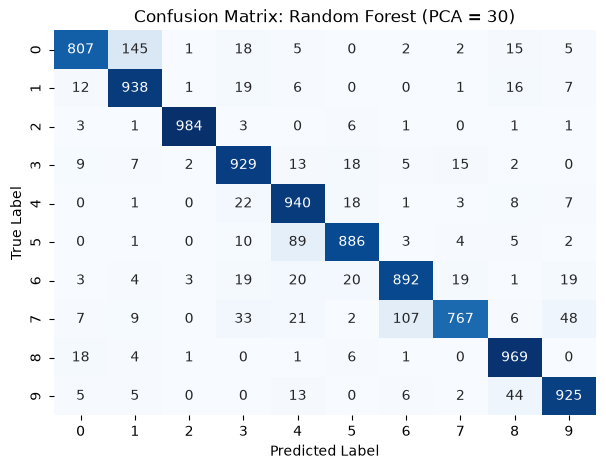

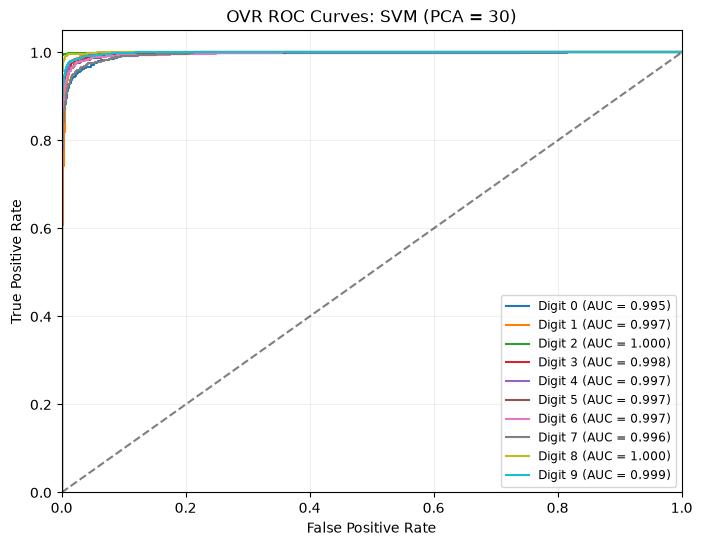

In [10]:

# =====================================================================
# PLOTTING UTILITIES
# =====================================================================
def plot_confusion_matrix(results, n_components, model_name):
    """Plots a heatmap visualization of the Confusion Matrix for a specific run."""
    cm = results[n_components][model_name]['confusion_matrix']
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {model_name} (PCA = {n_components})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

def plot_multiclass_roc(results, n_components, model_name, binarized_labels, num_classes=10):
    """Plots individual OVR ROC curves for all 10 Kannada digits under a specific configuration."""
    y_prob = results[n_components][model_name]['y_prob']
    
    plt.figure(figsize=(8, 6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(binarized_labels[:, i], y_prob[:, i])
        class_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Digit {i} (AUC = {class_auc:.3f})')
        
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'OVR ROC Curves: {model_name} (PCA = {n_components})')
    plt.legend(loc="lower right", fontsize='small')
    plt.grid(True, alpha=0.2)
    plt.show()

# Example breakdown targets to populate figures after execution completes:
plot_confusion_matrix(results_registry, n_components=30, model_name="Random Forest")
plot_multiclass_roc(results_registry, n_components=30, model_name="SVM", binarized_labels=y_test_binarized)